CNN Implementation

`Brain tumor detection`

> brain-tumor-mri-dataset  
[https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

tf.config.optimizer.set_jit(True)
mixed_precision.set_global_policy('mixed_float16')

print("Num GPUs Available:", len(gpus))
print("Mixed Precision Policy:", mixed_precision.global_policy())

I0000 00:00:1775498479.124152    1228 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775498481.120349    1228 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775498516.167077    1228 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Num GPUs Available: 1
Mixed Precision Policy: <DTypePolicy "mixed_float16">


In [3]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

In [4]:
BATCH_SIZE = 16
IMAGE_SIZE = (224, 224)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    'datasets/brain-tumor-mri-dataset/Training',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
 )

test_dataset = tf.keras.utils.image_dataset_from_directory(
    'datasets/brain-tumor-mri-dataset/Testing',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

Found 5600 files belonging to 4 classes.


I0000 00:00:1775498550.106085    1228 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 1600 files belonging to 4 classes.


In [5]:
def normalize(x, y):
    return tf.cast(x, tf.float32) / 255.0, y

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(normalize, num_parallel_calls=AUTOTUNE).shuffle(256).prefetch(1)
test_dataset = test_dataset.map(normalize, num_parallel_calls=AUTOTUNE).prefetch(1)

I0000 00:00:1775498568.437246    1551 shuffle_dataset_op.cc:453] ShuffleDatasetV3:16: Filling up shuffle buffer (this may take a while): 216 of 256
I0000 00:00:1775498569.144261    1551 shuffle_dataset_op.cc:483] Shuffle buffer filled.


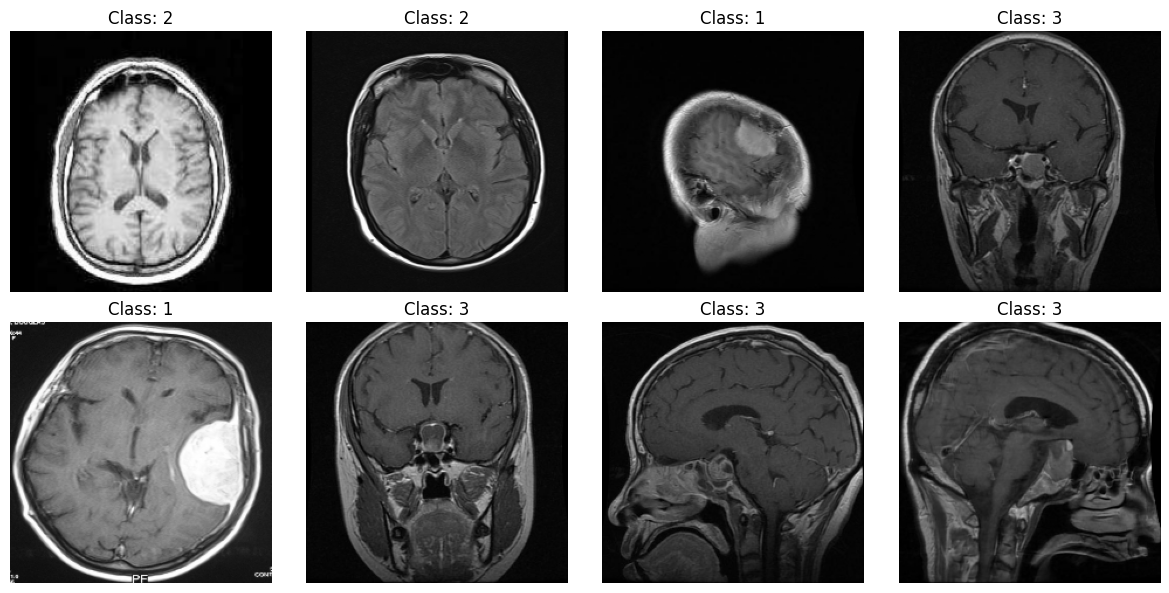

W0000 00:00:1775498570.431850    1228 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16777472 bytes after encountering the first element of size 16777472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


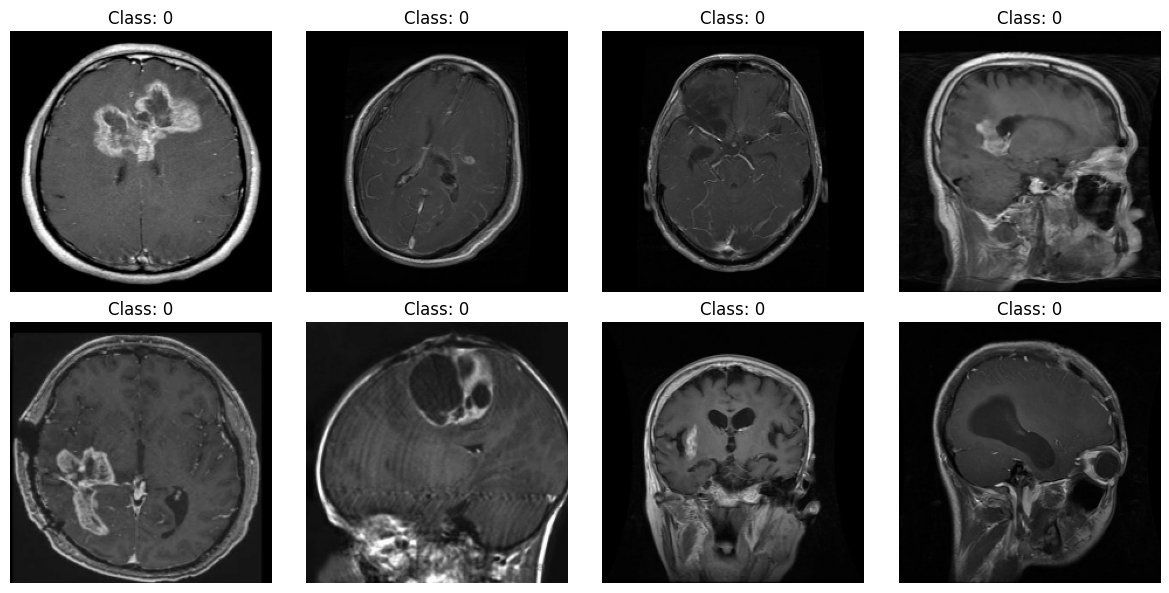

In [6]:
import math

def plot_images(images, labels):
    num_images = images.shape[0]
    num_rows = int(math.ceil(num_images / 4))
    fig, axes = plt.subplots(num_rows, 4, figsize=(12, 3 * num_rows))
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    for i in range(num_images):
        row = i // 4
        col = i % 4
        axes[row, col].imshow(images[i])
        axes[row, col].set_title(f"Class: {np.argmax(labels[i])}")
        axes[row, col].axis('off')
    for i in range(num_images, num_rows * 4):
        row = i // 4
        col = i % 4
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

for images, labels in train_dataset.take(1):
    plot_images(images.numpy()[:8], labels.numpy()[:8])

for images, labels in test_dataset.take(1):
    plot_images(images.numpy()[:8], labels.numpy()[:8])

In [7]:
model = Sequential([
  Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
  MaxPooling2D(2, 2),
  Conv2D(64, (3, 3), activation='relu'),
  MaxPooling2D(2, 2),
  Conv2D(32, (3, 3), activation='relu'),
  MaxPooling2D(2, 2),
  Conv2D(16, (3, 3), activation='relu'),
  MaxPooling2D(2, 2),
  Conv2D(8, (3, 3), activation='relu'),
  MaxPooling2D(2, 2),
  Flatten(),
  Dense(16, activation='relu'),
  Dense(8, activation='relu'),
  Dense(4, activation='softmax', dtype='float32')
])

/mnt/d/B.Tech/ProjeX/MachineLearning/Deeplearning/.ubuntu-venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
history = model.fit(train_dataset, epochs=50, validation_data=test_dataset, verbose=1)

Epoch 1/50


I0000 00:00:1775498575.866127    1483 service.cc:153] XLA service 0x7cee44030320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775498575.866166    1483 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775498575.923520    1483 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775498576.373970    1483 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1775498582.499080    1481 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775498583.596044    1481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3613__.83


350/350 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.5516 - loss: 1.1114 - val_accuracy: 0.6325 - val_loss: 1.1879
Epoch 2/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.7450 - loss: 0.7860 - val_accuracy: 0.7006 - val_loss: 1.0387
Epoch 3/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.7893 - loss: 0.6256 - val_accuracy: 0.7075 - val_loss: 0.9659
Epoch 4/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8289 - loss: 0.5173 - val_accuracy: 0.7656 - val_loss: 0.8665
Epoch 5/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8396 - loss: 0.4605 - val_accuracy: 0.7750 - val_loss: 0.8220
Epoch 6/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8695 - loss: 0.4003 - val_accuracy: 0.7725 - val_loss: 0.8798
Epoch 7/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8773 - loss: 0.3642 - val_accuracy: 0.7325 - val_loss: 1.0843
Epoch 8/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8891 - loss: 0.3270 - val_accurac

In [10]:
model.save('outputs/model_50epochs_fast.h5')

In [11]:
model.save('outputs/model_50epochs_fast.keras')